In [33]:
import numpy as np
import pandas as pd
import warnings
import matplotlib.pyplot as plt
import seaborn as sns

In [34]:
# Master
products = pd.read_csv('data\\products.csv')
customers = pd.read_csv('data\\customers.csv')
promotions = pd.read_csv('data\\promotions.csv')
geography = pd.read_csv('data\\geography.csv')
# transaction
orders = pd.read_csv('data\\orders.csv')
order_items = pd.read_csv('data\\order_items.csv')    
shipment = pd.read_csv('data\\shipments.csv')
returns = pd.read_csv('data\\returns.csv')
# Analytical
sales = pd.read_csv('data\\sales.csv')
# Operational
inventory = pd.read_csv('data\\inventory.csv')
web_traffic = pd.read_csv('data\\web_traffic.csv')


### DATAPROCESS

In [35]:
import pandas as pd
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

# 1. Đọc dữ liệu
df = pd.read_csv('data\\order_items.csv', usecols=['order_id', 'product_id'])

# 2. Lọc bỏ các sản phẩm "hiếm"
min_support_threshold = 0.01 
total_orders = df['order_id'].nunique()
min_orders_required = total_orders * min_support_threshold

item_order_counts = df.groupby('product_id')['order_id'].nunique()
frequent_items_list = item_order_counts[item_order_counts >= min_orders_required].index
df_filtered = df[df['product_id'].isin(frequent_items_list)]

# 3. Tạo transactions
transactions = df_filtered.groupby('order_id')['product_id'].apply(list).values

# 4. Xây dựng Sparse Matrix
te = TransactionEncoder()
te_ary = te.fit(transactions).transform(transactions, sparse=True)

basket_sparse = pd.DataFrame.sparse.from_spmatrix(te_ary, columns=te.columns_)

# ==========================================
# CÁCH KHẮC PHỤC LỖI TẠI ĐÂY
# Chuyển đổi tên cột (product_id) từ số nguyên (int) sang chuỗi (string)
basket_sparse.columns = [str(i) for i in basket_sparse.columns]
# ==========================================

# 5. Chạy Apriori
print("Đang chạy Apriori, vui lòng đợi...")
frequent_itemsets = apriori(basket_sparse, min_support=min_support_threshold, use_colnames=True)

frequent_itemsets = frequent_itemsets.sort_values(by='support', ascending=False)
print("\n--- Các tập sản phẩm phổ biến ---")
print(frequent_itemsets.head())

# 6. Rút trích luật kết hợp
if not frequent_itemsets.empty:
    rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1.0)
    rules = rules.sort_values(by='confidence', ascending=False)
    print("\n--- Các luật kết hợp ---")
    print(rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head())
else:
    print("\nKhông tìm thấy tập sản phẩm nào đạt ngưỡng min_support.")

Đang chạy Apriori, vui lòng đợi...

--- Các tập sản phẩm phổ biến ---
    support           itemsets
4  0.151864   frozenset({792})
3  0.151550   frozenset({791})
2  0.121297   frozenset({604})
7  0.118442  frozenset({2045})
1  0.110879   frozenset({487})

--- Các luật kết hợp ---
        antecedents       consequents   support  confidence      lift
1  frozenset({791})  frozenset({792})  0.077098    0.508729  3.349898
0  frozenset({792})  frozenset({791})  0.077098    0.507677  3.349898


In [36]:
import pandas as pd
import numpy as np

print("--- XÂY DỰNG LẠI DEMAND_DF VÀ BẢN ĐỒ NHU CẦU KỲ VỌNG ---")

# ==========================================
# 1. ĐỌC DỮ LIỆU VÀ GHÉP TRỤC THỜI GIAN
# ==========================================


order_items['promo_id'] = order_items['promo_id'].fillna('No_Promo')
order_items['is_promoted'] = np.where(order_items['promo_id'] == 'No_Promo', 0, 1)
order_items_enhanced = pd.merge(
    order_items,
    # Chỉ chọn những cột thực sự mang lại ý nghĩa tính toán để tránh làm phình dữ liệu
    promotions[['promo_id', 'promo_type', 'discount_value', 'min_order_value']], 
    on='promo_id',
    how='left'
)

item_with_date = pd.merge(
    order_items,
    orders[['order_id', 'order_date', 'order_status']], 
    on='order_id', 
    how='left'
)

# ==========================================
# 2. TỔNG HỢP DEMAND_DF THEO NGÀY
# ==========================================

# Gom nhóm theo ngày để đếm tổng số sản phẩm và số lượng đơn hàng duy nhất
demand_df = item_with_date.groupby('order_date').agg(
    total_items_sold=('quantity', 'sum'),           # Số sản phẩm bán ra thực tế
    unique_orders=('order_id', 'nunique')           # Số đơn hàng thực tế
).reset_index()

# Đổi tên cột cho đồng nhất và chuyển sang định dạng datetime
demand_df = demand_df.rename(columns={'order_date': 'Date'})
demand_df['Date'] = pd.to_datetime(demand_df['Date'])

# ==========================================
# 3. TẠO BẢN ĐỒ NHU CẦU KỲ VỌNG (CHỐNG LEAKAGE)
# ==========================================
# Lấy ra tháng và thứ trong tuần
demand_df['month'] = demand_df['Date'].dt.month
demand_df['day_of_week'] = demand_df['Date'].dt.dayofweek

# Tính trung vị (median) để tạo giá trị kỳ vọng áp dụng được cho tương lai
expected_demand_map = demand_df.groupby(['month', 'day_of_week']).agg(
    expected_items_sold=('total_items_sold', 'median'), 
    expected_unique_orders=('unique_orders', 'median')
).reset_index()

print("-> Xây dựng demand_df và Bản đồ Nhu cầu thành công!")
print(expected_demand_map.head())

--- XÂY DỰNG LẠI DEMAND_DF VÀ BẢN ĐỒ NHU CẦU KỲ VỌNG ---
-> Xây dựng demand_df và Bản đồ Nhu cầu thành công!
   month  day_of_week  expected_items_sold  expected_unique_orders
0      1            0                548.0                   104.0
1      1            1                489.0                    95.0
2      1            2                404.0                    76.0
3      1            3                386.0                    77.0
4      1            4                391.0                    79.0


Trích xuất đặc trưng khách hàng

In [37]:
promos = promotions.copy()
promos['start_date'] = pd.to_datetime(promos['start_date'])

customer_orders = pd.merge(
    orders[['order_id', 'customer_id', 'order_date']],
    order_items[['order_id', 'product_id', 'quantity', 'promo_id']],
    on='order_id',
    how='left'
)
customer_orders = pd.merge(
    customer_orders,
    customers,
    on='customer_id',
    how='left'
)

In [38]:
import pandas as pd

# Đọc dữ liệu
orders = pd.read_csv('data/orders.csv')
customers = pd.read_csv('data/customers.csv')

# Gộp hai bảng theo customer_id
merged = pd.merge(orders, customers, on='customer_id', how='left')

# Đảm bảo order_date là kiểu ngày
merged['order_date'] = pd.to_datetime(merged['order_date'])

# Đếm số lượng khách hàng theo nhóm tuổi mỗi ngày
result = merged.groupby(['order_date', 'age_group'])['customer_id'].nunique().reset_index(name='num_customers')
# Sau khi đã có result như hướng dẫn trước:
pivot_result = result.pivot(index='order_date', columns='age_group', values='num_customers').fillna(0).astype(int)
pivot_result = pivot_result.reset_index()
print(pivot_result)

age_group order_date  18-24  25-34  35-44  45-54  55+
0         2012-07-04     16     40     50     38   17
1         2012-07-05      9     29     23     28    8
2         2012-07-06     13     27     24     22    7
3         2012-07-07     10     27     12     17    7
4         2012-07-08     11     20     32     18    6
...              ...    ...    ...    ...    ...  ...
3828      2022-12-27     10     40     29     16   12
3829      2022-12-28     23     67     29     30   14
3830      2022-12-29     23     38     36     31   15
3831      2022-12-30     12     39     23     21   11
3832      2022-12-31     10     23     25     11    5

[3833 rows x 6 columns]


In [39]:
import numpy as np

# Tạo dải ngày
date_range = pd.date_range(start=pivot_result['order_date'].min(), end='2024-07-01')

# Tạo DataFrame ngày
date_df = pd.DataFrame({'order_date': date_range})

# Merge với bảng pivot
full_df_1 = date_df.merge(pivot_result, on='order_date', how='left')
full_df_1["week_of_year"] = full_df_1['order_date'].dt.isocalendar().week
full_df_1["year"] = full_df_1['order_date'].dt.year
full_df_1["month"] = full_df_1['order_date'].dt.month
full_df_1["date"] = full_df_1['order_date'].dt.dayofweek
full_df_1["day_of_week"] = full_df_1['order_date'].dt.dayofweek

full_df_2 = full_df_1.groupby(['week_of_year',  'day_of_week']).agg(
    expected_18_24=('18-24', 'mean'),             
    expected_25_34=('25-34', 'mean'),             
    expected_35_44=('35-44', 'mean'),             
    expected_45_54=('45-54', 'mean'),             
    expected_55_plus=('55+', 'mean'),             
).reset_index().rename(columns={
    '18_24': 'expected_18_24',
    '25_34': 'expected_25_34',
    '35_44': 'expected_35_44',
    '45_54': 'expected_45_54',
    '55_plus': 'expected_55_plus'
})

print(full_df_2.head())

   week_of_year  day_of_week  expected_18_24  expected_25_34  expected_35_44  \
0             1            0            30.9            63.2            55.6   
1             1            1            25.9            52.9            47.1   
2             1            2            17.2            36.0            31.8   
3             1            3            11.7            26.7            27.3   
4             1            4             8.2            18.2            13.6   

   expected_45_54  expected_55_plus  
0            37.6              23.5  
1            34.5              20.1  
2            22.6              14.6  
3            19.9               9.2  
4            11.5               7.8  


In [40]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# ==========================================
# 1. TẠO KHUNG THỜI GIAN CƠ BẢN (2012 - 2024)
# ==========================================
# Phạm vi dữ liệu theo đề bài: từ 04/07/2012 đến 01/07/2024 [cite: 19, 115]
start_date = '2012-07-04'
end_date = '2024-07-01'
df_calendar = pd.DataFrame({'Date': pd.date_range(start=start_date, end=end_date)})
sales['Date'] = pd.to_datetime(sales['Date'])
df_calendar = df_calendar.merge(sales[['Date', 'Revenue', 'COGS']], on='Date', how='left')

# --- 1.1 Đặc trưng Lịch biểu & Chu kỳ (Lượng giác) ---
df_calendar['day_of_week'] = df_calendar['Date'].dt.dayofweek
df_calendar['day_of_month'] = df_calendar['Date'].dt.day
df_calendar['month'] = df_calendar['Date'].dt.month
df_calendar['quarter'] = df_calendar['Date'].dt.quarter
df_calendar['is_weekend'] = df_calendar['day_of_week'].apply(lambda x: 1 if x >= 5 else 0)
# Chuyển đổi tính chu kỳ (Seasonality) bằng hàm Sin/Cos
day_of_year = df_calendar['Date'].dt.dayofyear
df_calendar['sin_365'] = np.sin(2 * np.pi * day_of_year / 365.25)
df_calendar['cos_365'] = np.cos(2 * np.pi * day_of_year / 365.25)

# ==========================================
# 2. TÍCH HỢP DỮ LIỆU KHUYẾN MÃI (PROMOTIONS)
# ==========================================

promos['start_date'] = pd.to_datetime(promos['start_date'])
promos['end_date'] = pd.to_datetime(promos['end_date'])

# Tính toán các chỉ số khuyến mãi cho từng ngày (Hợp lệ cho cả tương lai)
promo_stats = []
for current_date in df_calendar['Date']:
    active = promos[(promos['start_date'] <= current_date) & (promos['end_date'] >= current_date)]
    if len(active) > 0:
        max_discount = active['discount_value'].max()
        is_stackable = 1 if active['stackable_flag'].sum() > 0 else 0
    else:
        max_discount = 0
        is_stackable = 0
    promo_stats.append({
        'Date': current_date,
        'active_promos_count': len(active),
        'max_discount_depth': max_discount,
        'is_stackable_day': is_stackable
    })

df_calendar = pd.merge(df_calendar, pd.DataFrame(promo_stats), on='Date', how='left')


# ==========================================
# TRAFFIC KỲ VỌNG (CHỐNG LEAKAGE)
# ==========================================
# Sử dụng giá trị trung bình lịch sử theo thứ trong tuần và tuần trong năm

web_traffic['date'] = pd.to_datetime(web_traffic['date'])
web_traffic['week_of_year'] = web_traffic['date'].dt.isocalendar().week
web_traffic['day_of_week'] = web_traffic['date'].dt.dayofweek

historical_traffic = web_traffic.groupby(['week_of_year', 'day_of_week']).agg({
    'sessions': 'mean',
    'unique_visitors': 'mean',
    'bounce_rate': 'mean'
}).reset_index().rename(columns={
    'sessions': 'expected_sessions',
    'unique_visitors': 'expected_unique_visitors',
    'bounce_rate': 'expected_bounce_rate'
})

df_calendar['week_of_year'] = df_calendar['Date'].dt.isocalendar().week
df_calendar = pd.merge(df_calendar, historical_traffic, on=['week_of_year', 'day_of_week'], how='left')

print("Khởi tạo bảng df_calendar thành công!")
print(df_calendar.head())

Khởi tạo bảng df_calendar thành công!
        Date     Revenue        COGS  day_of_week  day_of_month  month  \
0 2012-07-04  5123547.94  3982991.19            2             4      7   
1 2012-07-05  2751773.45  2150580.23            3             5      7   
2 2012-07-06  3054029.42  2517632.84            4             6      7   
3 2012-07-07  2667930.94  2108246.62            5             7      7   
4 2012-07-08  2360851.90  1808622.79            6             8      7   

   quarter  is_weekend   sin_365   cos_365  active_promos_count  \
0        3           0 -0.058026 -0.998315                    0   
1        3           0 -0.075190 -0.997169                    0   
2        3           0 -0.092331 -0.995728                    0   
3        3           1 -0.109446 -0.993993                    0   
4        3           1 -0.126528 -0.991963                    0   

   max_discount_depth  is_stackable_day  week_of_year  expected_sessions  \
0                 0.0                 

Thêm đặc trưng về độ tuổi khách hàng

In [41]:
df_calendar = pd.merge(df_calendar, full_df_2, on=['week_of_year', 'day_of_week'], how='left')
df_calendar.drop(columns=['week_of_year'], inplace=True)
print(df_calendar.head())

        Date     Revenue        COGS  day_of_week  day_of_month  month  \
0 2012-07-04  5123547.94  3982991.19            2             4      7   
1 2012-07-05  2751773.45  2150580.23            3             5      7   
2 2012-07-06  3054029.42  2517632.84            4             6      7   
3 2012-07-07  2667930.94  2108246.62            5             7      7   
4 2012-07-08  2360851.90  1808622.79            6             8      7   

   quarter  is_weekend   sin_365   cos_365  ...  max_discount_depth  \
0        3           0 -0.058026 -0.998315  ...                 0.0   
1        3           0 -0.075190 -0.997169  ...                 0.0   
2        3           0 -0.092331 -0.995728  ...                 0.0   
3        3           1 -0.109446 -0.993993  ...                 0.0   
4        3           1 -0.126528 -0.991963  ...                 0.0   

   is_stackable_day  expected_sessions  expected_unique_visitors  \
0                 0            27708.2                   213

In [42]:
import pandas as pd
import numpy as np

print("--- ĐANG TRÍCH XUẤT HỒ SƠ HÀNH VI TỪ ORDERS ---")

# 1. Xử lý bảng orders gốc

orders['order_date'] = pd.to_datetime(orders['order_date'])
orders['month'] = orders['order_date'].dt.month
orders['day_of_week'] = orders['order_date'].dt.dayofweek

# Tạo cờ (flag) cho đơn hàng bị hủy
orders['is_cancelled'] = orders['order_status'].apply(lambda x: 1 if x == 'cancelled' else 0)

# 2. Xây dựng Hồ sơ Kỳ vọng theo Tháng và Thứ trong tuần
expected_orders_profile = orders.groupby(['month', 'day_of_week']).agg(
    expected_cancel_rate=('is_cancelled', 'mean') # Tỷ lệ hủy đơn trung bình
).reset_index()

# 3. Tính Giá trị đơn hàng trung bình (AOV) từ tập Sales
# Lấy bảng sales đã có doanh thu thực tế

sales['Date'] = pd.to_datetime(sales['Date'])
sales['month'] = sales['Date'].dt.month
sales['day_of_week'] = sales['Date'].dt.dayofweek

# Tính AOV = Revenue / Unique Orders (Lấy dữ liệu từ demand_df bạn đã làm trước đó)
# Giả sử bạn kết hợp Sales và số lượng đơn để tính AOV Kỳ vọng
aov_df = pd.merge(sales, demand_df[['Date', 'unique_orders']], on='Date', how='left')
aov_df['daily_AOV'] = aov_df['Revenue'] / aov_df['unique_orders'].replace(0, np.nan)

expected_AOV_profile = aov_df.groupby(['month', 'day_of_week']).agg(
    expected_aov=('daily_AOV', 'median') # Dùng median để chống nhiễu
).reset_index()


# 4. Bơm 2 vũ khí này vào không gian đặc trưng df_calendar
df_calendar['month'] = df_calendar['Date'].dt.month
df_calendar['day_of_week'] = df_calendar['Date'].dt.dayofweek

df_calendar = pd.merge(df_calendar, expected_orders_profile, on=['month', 'day_of_week'], how='left')
df_calendar = pd.merge(df_calendar, expected_AOV_profile, on=['month', 'day_of_week'], how='left')

# Lấp đầy NaN bằng giá trị trung vị của toàn bộ lịch sử (để an toàn cho tập Test)
df_calendar['expected_cancel_rate'] = df_calendar['expected_cancel_rate'].fillna(df_calendar['expected_cancel_rate'].median())
df_calendar['expected_aov'] = df_calendar['expected_aov'].fillna(df_calendar['expected_aov'].median())

print("-> Tích hợp thành công: Expected Cancel Rate và Expected AOV")

--- ĐANG TRÍCH XUẤT HỒ SƠ HÀNH VI TỪ ORDERS ---
-> Tích hợp thành công: Expected Cancel Rate và Expected AOV


In [43]:
item_with_date = pd.merge(
    order_items_enhanced,
    orders[['order_id', 'order_date', 'order_status']], 
    on='order_id',
    how='left'
)

In [44]:
df_calendar['Date'] = pd.to_datetime(df_calendar['Date'])
df_calendar['month'] = df_calendar['Date'].dt.month
df_calendar['day_of_week'] = df_calendar['Date'].dt.dayofweek

# Nối bản đồ nhu cầu vào df_calendar
df_calendar = pd.merge(df_calendar, expected_demand_map, on=['month', 'day_of_week'], how='left')

# Lấp đầy các giá trị trống (nếu có) bằng giá trị trung vị tổng thể để mô hình không bị lỗi
median_items = df_calendar['expected_items_sold'].median()
median_orders = df_calendar['expected_unique_orders'].median()

df_calendar['expected_items_sold'] = df_calendar['expected_items_sold'].fillna(median_items)
df_calendar['expected_unique_orders'] = df_calendar['expected_unique_orders'].fillna(median_orders)

In [45]:
import pandas as pd
import numpy as np

print("--- 📦 TRÍCH XUẤT ĐẶC TRƯNG KỲ VỌNG TỪ INVENTORY ---")

# 1. Đọc dữ liệu Tồn kho


# Đảm bảo có cột month (trong file đã có sẵn nhưng cẩn thận vẫn hơn)
if 'month' not in inventory.columns:
    inventory['snapshot_date'] = pd.to_datetime(inventory['snapshot_date'])
    inventory['month'] = inventory['snapshot_date'].dt.month

# 2. Xây dựng Hồ sơ Tồn kho Kỳ vọng theo Tháng
# Lấy trung bình/trung vị các chỉ số sức khỏe kho hàng qua các năm
expected_inv_profile = inventory.groupby('month').agg(
    expected_fill_rate=('fill_rate', 'mean'),             # Tỷ lệ đáp ứng đơn hàng kỳ vọng
    expected_stockout_rate=('stockout_flag', 'mean'),     # Tỷ lệ cháy hàng kỳ vọng
    expected_overstock_rate=('overstock_flag', 'mean'),   # Tỷ lệ tồn kho dư thừa kỳ vọng
    expected_sell_through=('sell_through_rate', 'median') # Tốc độ bán hàng trung vị
).reset_index()

# 3. Bơm vào không gian đặc trưng df_calendar
# Giả sử df_calendar đã có cột 'month' (từ ngày Date)
if 'month' not in df_calendar.columns:
    df_calendar['month'] = df_calendar['Date'].dt.month

df_calendar = pd.merge(df_calendar, expected_inv_profile, on='month', how='left')

# Lấp đầy NaN (phòng trường hợp có tháng không có dữ liệu) bằng trung vị toàn cục
for col in ['expected_fill_rate', 'expected_stockout_rate', 'expected_overstock_rate', 'expected_sell_through']:
    df_calendar[col] = df_calendar[col].fillna(expected_inv_profile[col].median())

print("-> ✅ Tích hợp thành công 4 đặc trưng Inventory!")
print(expected_inv_profile.head())

--- 📦 TRÍCH XUẤT ĐẶC TRƯNG KỲ VỌNG TỪ INVENTORY ---
-> ✅ Tích hợp thành công 4 đặc trưng Inventory!
   month  expected_fill_rate  expected_stockout_rate  expected_overstock_rate  \
0      1            0.964975                0.662592                 0.839022   
1      2            0.963565                0.667834                 0.806437   
2      3            0.961840                0.668562                 0.755280   
3      4            0.956875                0.686933                 0.670141   
4      5            0.959155                0.681063                 0.709009   

   expected_sell_through  
0                0.07270  
1                0.08740  
2                0.11225  
3                0.15380  
4                0.14290  


In [46]:
# ==========================================
# BƯỚC 2: MERGE DF_CALENDAR VÀO DỮ LIỆU ĐỂ TẠO TẬP TRAIN & TEST
# ==========================================

# 1. XỬ LÝ TẬP TRAIN (final_df)
# Đọc dữ liệu bán hàng lịch sử (chứa target Revenue và COGS)

sales['Date'] = pd.to_datetime(sales['Date'])
final_df = df_calendar
# Merge df_calendar vào sales. 

# Sắp xếp lại theo thời gian (Rất quan trọng cho việc gán trọng số và Cross-Validation)
final_df = final_df.sort_values('Date').reset_index(drop=True)

# Giữ nguyên logic của demo_before: Cắt bỏ dữ liệu năm 2012 vì chứa nhiều nhiễu/bất thường
#final_df = final_df[final_df['Date'] >= '2013-01-01'].reset_index(drop=True)

# Đảm bảo các cột phân loại (nếu có) được định dạng đúng cho LightGBM
for col in final_df.select_dtypes(include=['object']).columns:
    final_df[col] = final_df[col].astype('category')

final_df['time_step'] = np.arange(len(final_df))

# 2. XỬ LÝ TẬP TEST (future_df)
# Đọc file mẫu từ Kaggle để lấy trục thời gian cần dự báo
sample_sub = pd.read_csv('data\\sample_submission.csv')
sample_sub['Date'] = pd.to_datetime(sample_sub['Date'])

# Merge đặc trưng từ df_calendar cho tương lai (chính là không gian đặc trưng y hệt tập Train)
future_df = pd.merge(sample_sub[['Date']], df_calendar, on='Date', how='left')
future_df['time_step'] = np.arange(len(future_df))

for col in future_df.select_dtypes(include=['object']).columns:
    future_df[col] = future_df[col].astype('category')

print("Hoàn tất Bước 2: Hợp nhất dữ liệu!")
print(f"Kích thước tập Train (final_df): {final_df.shape}")
print(f"Kích thước tập Test (future_df): {future_df.shape}")
print("\nXem thử 5 dòng đầu tập Train:")
print(final_df.head())

Hoàn tất Bước 2: Hợp nhất dữ liệu!
Kích thước tập Train (final_df): (4381, 30)
Kích thước tập Test (future_df): (548, 30)

Xem thử 5 dòng đầu tập Train:
        Date     Revenue        COGS  day_of_week  day_of_month  month  \
0 2012-07-04  5123547.94  3982991.19            2             4      7   
1 2012-07-05  2751773.45  2150580.23            3             5      7   
2 2012-07-06  3054029.42  2517632.84            4             6      7   
3 2012-07-07  2667930.94  2108246.62            5             7      7   
4 2012-07-08  2360851.90  1808622.79            6             8      7   

   quarter  is_weekend   sin_365   cos_365  ...  expected_55_plus  \
0        3           0 -0.058026 -0.998315  ...         21.727273   
1        3           0 -0.075190 -0.997169  ...         18.000000   
2        3           0 -0.092331 -0.995728  ...         12.818182   
3        3           1 -0.109446 -0.993993  ...          8.727273   
4        3           1 -0.126528 -0.991963  ...         1

In [47]:
final2_df = final_df
final_df = final_df[final_df['Date'] < '2023-01-01'].reset_index(drop=True)

### TRAIN

In [48]:
from sklearn.linear_model import Ridge
import lightgbm as lgb
train_df = final_df.iloc[:-(548*2)].copy()
val_df = final_df.iloc[-(548*2):-548].copy()

cols_to_drop = ['Date', 'Revenue', 'COGS']
deterministic_features = [col for col in final_df.columns if col not in cols_to_drop]

# ----------------- PHẦN 1: TÌM XU HƯỚNG TỔNG QUÁT -----------------
from sklearn.linear_model import HuberRegressor
# Thay cho Ridge(alpha=10.0)
trend_model = HuberRegressor(epsilon=1.35)
# Fit trên time_step
trend_model.fit(train_df[['time_step']], train_df['Revenue'])

# Tính Trend cho Train và Val
train_df['Trend'] = trend_model.predict(train_df[['time_step']])
val_df['Trend'] = trend_model.predict(val_df[['time_step']])

# Tính phần dư (Residuals) - Lượng dao động cần mô hình Cây giải quyết
train_df['Residuals'] = train_df['Revenue'] - train_df['Trend']

lgb_model = lgb.LGBMRegressor(n_estimators=500, random_state=42)
lgb_model.fit(
    train_df[deterministic_features], 
    train_df['Residuals']
)

# ----------------- PHẦN 3: HỢP NHẤT DỰ BÁO TƯƠNG LAI --------------
# LightGBM dự đoán phần dao động của tập Val
val_df['Predicted_Residuals'] = lgb_model.predict(val_df[deterministic_features])

# Tổng hợp = Trend + Dao động dự báo
val_df['Final_Revenue_Pred'] = val_df['Trend'] + val_df['Predicted_Residuals']

# Đảm bảo doanh thu không bị âm
val_df['Final_Revenue_Pred'] = np.clip(val_df['Final_Revenue_Pred'], a_min=0, a_max=None)

In [49]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Đánh giá trên tập Validation
rmse = np.sqrt(mean_squared_error(val_df['Revenue'], val_df['Final_Revenue_Pred']))
mae = mean_absolute_error(val_df['Revenue'], val_df['Final_Revenue_Pred'])
r2 = r2_score(val_df['Revenue'], val_df['Final_Revenue_Pred'])

print(f"Validation RMSE: {rmse:,.2f}")
print(f"Validation MAE: {mae:,.2f}")
print(f"Validation R2: {r2:.4f}")

Validation RMSE: 1,056,924.29
Validation MAE: 750,338.57
Validation R2: 0.6353


### SHAP + TIME-CROSS_VALIDATION

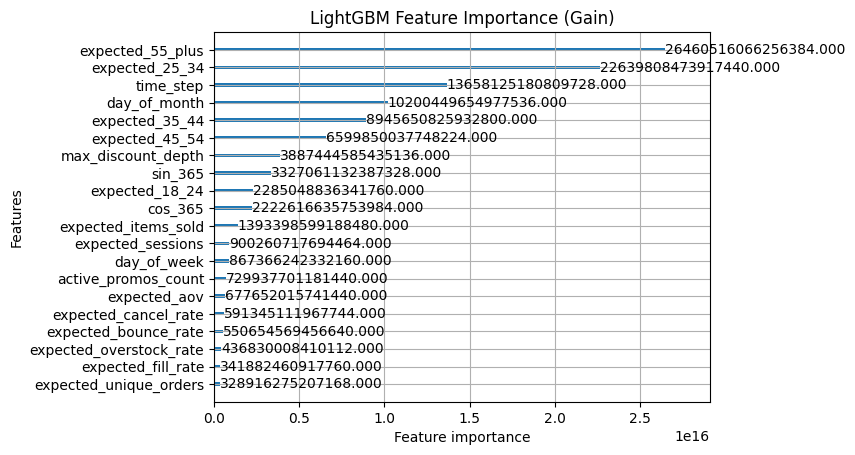

In [50]:
lgb.plot_importance(lgb_model, importance_type='gain', max_num_features=20, title="LightGBM Feature Importance (Gain)")
plt.show()

In [51]:
import numpy as np
import pandas as pd
import lightgbm as lgb
from sklearn.linear_model import Ridge
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def evaluate_hybrid_cv(final_df, deterministic_features, n_splits=5, test_size=548):
    print("=== ĐANG CHẠY CROSS-VALIDATION CHO HYBRID MODEL (RIDGE + LIGHTGBM) ===\n")
    
    # Bắt buộc: Đảm bảo dữ liệu sắp xếp theo chiều mũi tên thời gian
    final_df = final_df.sort_values('Date').reset_index(drop=True)
    
    # Trục thời gian t dùng cho mô hình Linear (Ridge)
    final_df['time_step'] = np.arange(len(final_df))
    
    # Cấu hình TimeSeriesSplit với kích thước tập Validation cố định (ví dụ 1.5 năm = ~548 ngày)
    tscv = TimeSeriesSplit(n_splits=n_splits, test_size=test_size)
    
    metrics = {'rmse': [], 'mae': [], 'r2': []}
    
    for fold, (train_idx, val_idx) in enumerate(tscv.split(final_df)):
        # 1. Tách tập Train và Validation cho Fold hiện tại
        train_df = final_df.iloc[train_idx].copy()
        val_df = final_df.iloc[val_idx].copy()
        
        # ---------------- PHẦN 1: TÌM XU HƯỚNG TỔNG QUÁT BẰNG RIDGE ----------------
        trend_model = Ridge(alpha=10.0)
        trend_model.fit(train_df[['time_step']], train_df['Revenue'])
        
        # Lấy Trend cho cả Train và Val
        train_df['Trend'] = trend_model.predict(train_df[['time_step']])
        val_df['Trend'] = trend_model.predict(val_df[['time_step']])
        
        # Bóc tách Trend ra khỏi Doanh thu để lấy Phần dư (Residuals)
        train_df['Residuals'] = train_df['Revenue'] - train_df['Trend']
        val_df_actual_residuals = val_df['Revenue'] - val_df['Trend']
        
        # ---------------- PHẦN 2: DỰ ĐOÁN DAO ĐỘNG BẰNG LIGHTGBM ----------------
        lgb_model = lgb.LGBMRegressor(
            n_estimators=1000, 
            learning_rate=0.03,
            random_state=42, 
            n_jobs=-1,
            verbose=-1
        )
        
        # Cho LightGBM học trên mảng Residuals (Đã triệt tiêu Trend)
        lgb_model.fit(
            train_df[deterministic_features], 
            train_df['Residuals'],
            eval_set=[(val_df[deterministic_features], val_df_actual_residuals)],
            callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)]
        )
        
        # ---------------- PHẦN 3: HỢP NHẤT VÀ ĐÁNH GIÁ ----------------
        # Dự đoán phần dư cho tập Val
        val_df['Pred_Residuals'] = lgb_model.predict(val_df[deterministic_features])
        
        # Ghép Trend và Dao động lại với nhau
        val_df['Final_Pred'] = val_df['Trend'] + val_df['Pred_Residuals']
        
        # Lọc nhiễu: Ép doanh thu âm về 0
        val_df['Final_Pred'] = np.clip(val_df['Final_Pred'], a_min=0, a_max=None)
        
        # ---------------- TÍNH TOÁN CHỈ SỐ ----------------
        rmse = np.sqrt(mean_squared_error(val_df['Revenue'], val_df['Final_Pred']))
        mae = mean_absolute_error(val_df['Revenue'], val_df['Final_Pred'])
        r2 = r2_score(val_df['Revenue'], val_df['Final_Pred'])
        
        metrics['rmse'].append(rmse)
        metrics['mae'].append(mae)
        metrics['r2'].append(r2)
        
        print(f"Fold {fold+1} | Train Size: {len(train_df)} | Val Size: {len(val_df)}")
        print(f"   ➤ RMSE: {rmse:,.2f} | MAE: {mae:,.2f} | R2: {r2:.4f}\n")
        
    # In ra trung bình tổng thể
    print("="*50)
    print("=== KẾT QUẢ TRUNG BÌNH CỦA HYBRID MODEL ===")
    print(f"Mean RMSE: {np.mean(metrics['rmse']):,.2f}")
    print(f"Mean MAE:  {np.mean(metrics['mae']):,.2f}")
    print(f"Mean R2:   {np.mean(metrics['r2']):.4f}")
    
    return metrics

# ---------------- CÁCH CHẠY THỬ ----------------
# Anh cần định nghĩa trước danh sách các đặc trưng (features) "chắc chắn biết trong tương lai"
features_list = [
    'day_of_week', 'day_of_month', 'day_of_year', 
    'week_of_year', 'month', 'quarter', 
    'is_weekend', 'is_month_start', 'is_month_end'
    # Thêm 'is_holiday', 'promotion_flag' nếu anh đã tạo
]

# Đảm bảo final_df của anh không có chứa dữ liệu NaN và chạy hàm
cv_results = evaluate_hybrid_cv(final_df, deterministic_features, n_splits=5, test_size=548)

=== ĐANG CHẠY CROSS-VALIDATION CHO HYBRID MODEL (RIDGE + LIGHTGBM) ===

Fold 1 | Train Size: 1093 | Val Size: 548
   ➤ RMSE: 1,873,175.57 | MAE: 1,255,561.16 | R2: 0.5550

Fold 2 | Train Size: 1641 | Val Size: 548
   ➤ RMSE: 1,669,721.57 | MAE: 1,269,095.85 | R2: 0.7340

Fold 3 | Train Size: 2189 | Val Size: 548
   ➤ RMSE: 2,457,648.69 | MAE: 2,099,424.77 | R2: -0.6230

Fold 4 | Train Size: 2737 | Val Size: 548
   ➤ RMSE: 995,168.27 | MAE: 686,889.59 | R2: 0.6767

Fold 5 | Train Size: 3285 | Val Size: 548
   ➤ RMSE: 742,622.72 | MAE: 572,458.54 | R2: 0.7713

=== KẾT QUẢ TRUNG BÌNH CỦA HYBRID MODEL ===
Mean RMSE: 1,547,667.36
Mean MAE:  1,176,685.98
Mean R2:   0.4228


Giai đoạn của Fold 3: Từ 2018-07-02 00:00:00 đến 2019-12-31 00:00:00


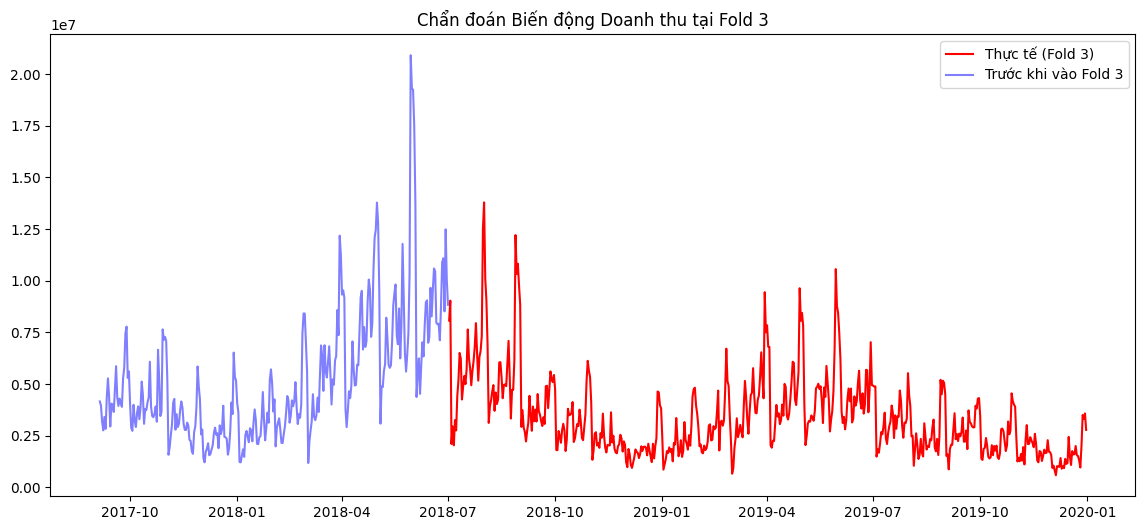

In [52]:
import matplotlib.pyplot as plt

def diagnose_fold_3(final_df, tscv_splits=5, test_size=548):
    # Lấy lại các index chia Fold
    tscv = TimeSeriesSplit(n_splits=tscv_splits, test_size=test_size)
    splits = list(tscv.split(final_df))
    
    # Lấy index của Fold 3 (vị trí số 2 trong list vì Python đếm từ 0)
    train_idx, val_idx = splits[2]
    
    val_df_fold3 = final_df.iloc[val_idx].copy()
    
    print(f"Giai đoạn của Fold 3: Từ {val_df_fold3['Date'].min()} đến {val_df_fold3['Date'].max()}")
    
    plt.figure(figsize=(14, 6))
    plt.plot(val_df_fold3['Date'], val_df_fold3['Revenue'], label='Thực tế (Fold 3)', color='red')
    
    # Vẽ thêm 1 khoảng thời gian của Train trước đó để xem độ gãy
    train_tail = final_df.iloc[train_idx[-300:]] # Lấy 300 ngày cuối của Train
    plt.plot(train_tail['Date'], train_tail['Revenue'], label='Trước khi vào Fold 3', color='blue', alpha=0.5)
    
    plt.title('Chẩn đoán Biến động Doanh thu tại Fold 3')
    plt.legend()
    plt.show()

diagnose_fold_3(final_df)

In [53]:
import numpy as np

# 1. Tách Target (Doanh thu và Giá vốn) từ tập Train (final_df)
y_train_revenue = final_df['Revenue']
y_train_cogs = final_df['COGS']

# 2. Tách Features (Đặc trưng) cho Train và Test
# Loại bỏ các cột không phải đặc trưng dự báo
cols_to_drop = ['Date', 'Revenue', 'COGS', 'Trend', 'Residuals', 'time_step'] 
deterministic_features = [col for col in final_df.columns if col not in cols_to_drop]

X_train = final_df[deterministic_features]
X_test = future_df[deterministic_features]

# 3. Khởi tạo Trọng số (w_train)
w_train = np.linspace(0.5, 1.5, len(X_train))

# 4. Khởi tạo best_params_rev và best_params_cogs 
# Nếu bạn chưa chạy Optuna để tối ưu siêu tham số, bạn có thể thiết lập một bộ tham số tốt (baseline) như sau:
best_params_rev = {
    'learning_rate': 0.03,
    'num_leaves': 31,           # Số lượng lá tối đa của cây
    'max_depth': -1,            # Không giới hạn độ sâu
    'min_child_samples': 20,    # Số mẫu tối thiểu trên mỗi lá
    'subsample': 0.8,           # Lấy mẫu ngẫu nhiên 80% dữ liệu mỗi lần học
    'colsample_bytree': 0.8     # Lấy mẫu ngẫu nhiên 80% đặc trưng
}

# Sử dụng chung tham số cho mô hình COGS (hoặc bạn có thể tinh chỉnh riêng)
best_params_cogs = best_params_rev.copy()

--- SO SÁNH DOANH THU: DỰ ĐOÁN (2023-2024) VS THỰC TẾ (2021-2022) ---
Tổng doanh thu thực tế (2020 - 2021): 1,691,669,924 VNĐ
Tổng doanh thu dự đoán (2023 - 2024): 2,468,590,566 VNĐ
Tốc độ tăng trưởng kỳ vọng (Growth Rate): 45.93%


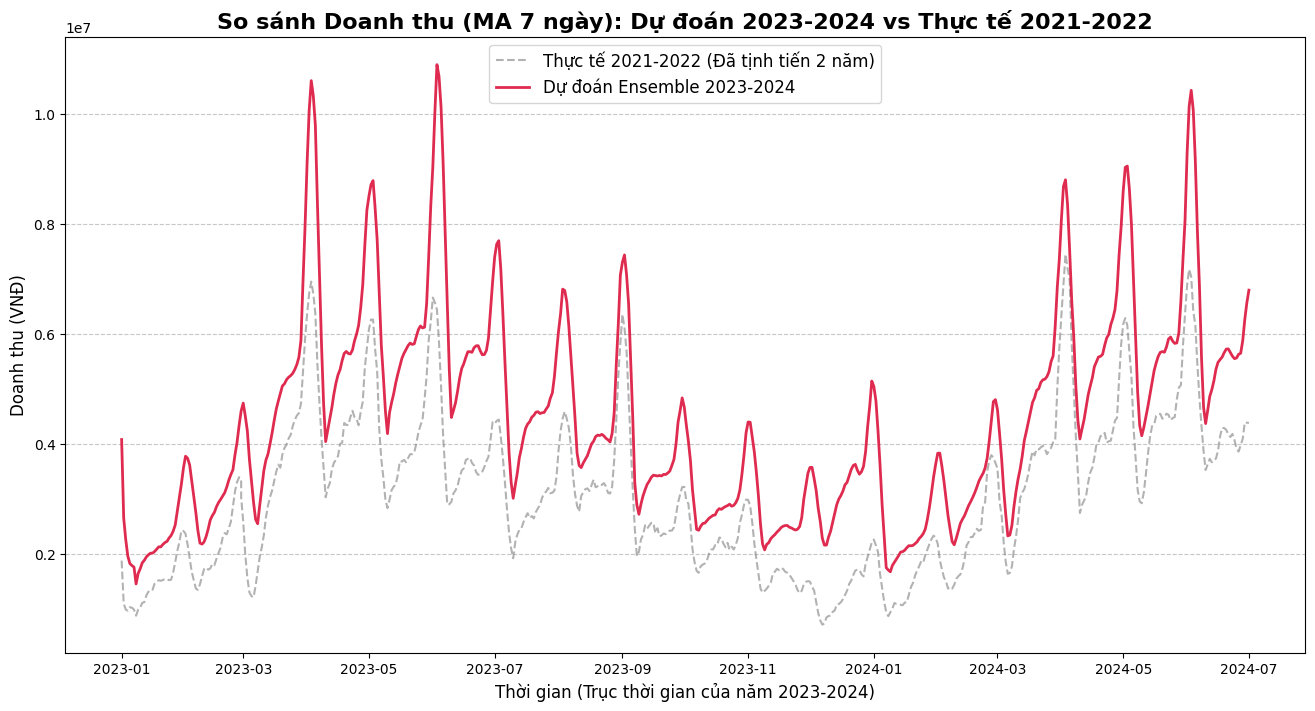

In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("--- SO SÁNH DOANH THU: DỰ ĐOÁN (2023-2024) VS THỰC TẾ (2021-2022) ---")

# 1. Đọc dữ liệu
# Dữ liệu dự đoán của bạn
sub_new = pd.read_csv('final_submission_fullfit.csv') # Đổi lại tên file nếu cần
sub_new['Date'] = pd.to_datetime(sub_new['Date'])

# Dữ liệu lịch sử thực tế (sales.csv)
sales = pd.read_csv('data\\sales.csv')
sales['Date'] = pd.to_datetime(sales['Date'])

# 2. Lọc mốc thời gian tương ứng
# Tập dự đoán kéo dài từ 01/01/2023 đến 01/07/2024
pred_df = sub_new[(sub_new['Date'] >= '2023-01-01') & (sub_new['Date'] <= '2024-07-01')].copy()

# Tập lịch sử tương ứng: Lùi lại đúng 2 năm (01/01/2021 đến 01/07/2022)
hist_df = sales[(sales['Date'] >= '2020-01-01') & (sales['Date'] <= '2021-07-01')].copy()

# 3. Tịnh tiến thời gian (Shift Date) để vẽ chung 1 trục X
# Cộng thêm 2 năm (chính xác là 730 ngày) vào dữ liệu lịch sử
hist_df['Shifted_Date'] = hist_df['Date'] + pd.DateOffset(years=3)

# 4. Làm mượt đồ thị (Smoothing) để dễ nhìn
# Doanh thu theo ngày rất nhiễu, ta dùng Trung bình trượt 7 ngày (Rolling 7-day)
pred_df['Revenue_Smooth'] = pred_df['Revenue'].rolling(window=7, min_periods=1).mean()
hist_df['Revenue_Smooth'] = hist_df['Revenue'].rolling(window=7, min_periods=1).mean()

# 5. In thống kê tổng quan (Sanity Check)
total_hist = hist_df['Revenue'].sum()
total_pred = pred_df['Revenue'].sum()
growth_rate = ((total_pred - total_hist) / total_hist) * 100

print(f"Tổng doanh thu thực tế (2020 - 2021): {total_hist:,.0f} VNĐ")
print(f"Tổng doanh thu dự đoán (2023 - 2024): {total_pred:,.0f} VNĐ")
print(f"Tốc độ tăng trưởng kỳ vọng (Growth Rate): {growth_rate:.2f}%")

# 6. Vẽ biểu đồ so sánh
plt.figure(figsize=(16, 8))

# Vẽ đường lịch sử (Màu xám, nét đứt để làm nền)
plt.plot(hist_df['Shifted_Date'], hist_df['Revenue_Smooth'], 
         label='Thực tế 2021-2022 (Đã tịnh tiến 2 năm)', 
         color='gray', alpha=0.6, linestyle='--', linewidth=1.5)

# Vẽ đường dự đoán (Màu xanh/đỏ nổi bật)
plt.plot(pred_df['Date'], pred_df['Revenue_Smooth'], 
         label='Dự đoán Ensemble 2023-2024', 
         color='crimson', alpha=0.9, linewidth=2)

# Cài đặt biểu đồ
plt.title('So sánh Doanh thu (MA 7 ngày): Dự đoán 2023-2024 vs Thực tế 2021-2022', fontsize=16, fontweight='bold')
plt.xlabel('Thời gian (Trục thời gian của năm 2023-2024)', fontsize=12)
plt.ylabel('Doanh thu (VNĐ)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Lưu đồ

In [55]:
# ==============================================================================
# PIPELINE HUẤN LUYỆN VÀ DỰ BÁO DOANH THU - THE GRIDBREAKER DATATHON
# ==============================================================================

import pandas as pd
import numpy as np
import lightgbm as lgb
import warnings
warnings.filterwarnings('ignore')

# ------------------------------------------------------------------------------
# BƯỚC 1: CHUẨN BỊ DỮ LIỆU (PREPARE DATA)
# ------------------------------------------------------------------------------
def prepare_modeling_data(final_df, future_df):
    """
    Tách tập đặc trưng (X), biến mục tiêu (y) và khởi tạo trọng số học (weights).
    """
    print("1. Đang chuẩn bị dữ liệu...")
    
    # Xác định biến mục tiêu (Target)
    y_train_rev = final_df['Revenue']
    y_train_cogs = final_df['COGS']
    
    # Xác định các cột không dùng làm đặc trưng đưa vào mô hình
    cols_to_drop = ['Date', 'Revenue', 'COGS', 'Trend', 'Residuals', 'time_step']
    deterministic_features = [col for col in final_df.columns if col not in cols_to_drop]
    
    # Khởi tạo X_train và X_test
    X_train = final_df[deterministic_features]
    X_test = future_df[deterministic_features]
    
    # Khởi tạo trọng số (Ưu tiên học dữ liệu gần hiện tại hơn)
    w_train = np.linspace(0.5, 1.5, len(X_train))
    
    print(f"   -> Kích thước X_train: {X_train.shape}")
    print(f"   -> Kích thước X_test: {X_test.shape}")
    
    return X_train, y_train_rev, y_train_cogs, X_test, w_train

# ------------------------------------------------------------------------------
# BƯỚC 2: HUẤN LUYỆN MÔ HÌNH VÀ DỰ BÁO (TRAIN & PREDICT)
# ------------------------------------------------------------------------------
def train_and_predict(X_train, y_train_rev, y_train_cogs, X_test, w_train):
    """
    Sử dụng LightGBM với Log Transform để dự báo Revenue và COGS.
    """
    print("2. Bắt đầu huấn luyện mô hình (Full-Fit 100% Data)...")
    
    # Chuyển Target sang thang Logarithmic (Triệt tiêu nhiễu/Outliers)
    y_train_rev_log = np.log1p(y_train_rev)
    y_train_cogs_log = np.log1p(y_train_cogs)
    
    # Cấu hình siêu tham số (Hyperparameters) cho LightGBM
    lgbm_params = {
        'learning_rate': 0.03,
        'num_leaves': 31,
        'max_depth': -1,
        'min_child_samples': 20,
        'subsample': 0.8,
        'colsample_bytree': 0.8,
        'n_estimators': 500,
        'random_state': 42,
        'verbose': -1
    }
    
    # Khởi tạo mô hình
    model_rev = lgb.LGBMRegressor(**lgbm_params)
    model_cogs = lgb.LGBMRegressor(**lgbm_params)
    
    # Tiến hành Fit (Có kèm trọng số)
    model_rev.fit(X_train, y_train_rev_log, sample_weight=w_train)
    model_cogs.fit(X_train, y_train_cogs_log, sample_weight=w_train)
    
    print("3. Đang đưa ra dự báo cho tập tương lai...")
    # Dự báo và chuyển đổi ngược từ Logarithmic (Inverse Log)
    preds_rev_log = model_rev.predict(X_test)
    preds_cogs_log = model_cogs.predict(X_test)
    
    # Ép các giá trị dự báo bị âm về 0 (np.maximum)
    preds_rev = np.maximum(0, np.expm1(preds_rev_log))
    preds_cogs = np.maximum(0, np.expm1(preds_cogs_log))
    
    return preds_rev, preds_cogs

# ------------------------------------------------------------------------------
# BƯỚC 3: ĐÓNG GÓI KẾT QUẢ NỘP BÀI (CREATE SUBMISSION)
# ------------------------------------------------------------------------------
def create_submission(preds_rev, preds_cogs, sample_sub_path='data/sample_submission.csv', output_name='submission_final.csv'):
    """
    Định dạng file CSV theo đúng chuẩn yêu cầu của hệ thống Kaggle.
    """
    print("4. Đang xuất file kết quả...")
    
    # Giữ nguyên định dạng và thứ tự Date của sample_submission[cite: 1]
    submission = pd.read_csv(sample_sub_path)
    submission['Revenue'] = preds_rev
    submission['COGS'] = preds_cogs
    
    # Lọc đúng 3 cột và xuất file (Tuyệt đối không lưu index)[cite: 1]
    submission = submission[['Date', 'Revenue', 'COGS']]
    submission.to_csv(output_name, index=False)
    
    print(f"✅ HOÀN TẤT! File '{output_name}' đã sẵn sàng để nộp lên Kaggle.")

# ==============================================================================
# KHỐI THỰC THI CHÍNH (MAIN EXECUTION)
# ==============================================================================
if __name__ == "__main__":
    # Đảm bảo bạn đã có biến `final_df` (Train) và `future_df` (Test) từ các bước Feature Engineering trước đó
    
    # 1. Gọi hàm chuẩn bị dữ liệu
    X_train, y_train_rev, y_train_cogs, X_test, w_train = prepare_modeling_data(final_df, future_df)
    
    # 2. Gọi hàm Train & Dự báo
    preds_rev, preds_cogs = train_and_predict(X_train, y_train_rev, y_train_cogs, X_test, w_train)
    
    # 3. Gọi hàm xuất file submission
    create_submission(preds_rev, preds_cogs, output_name='datathon_lightgbm_fullfit.csv')

1. Đang chuẩn bị dữ liệu...
   -> Kích thước X_train: (3833, 26)
   -> Kích thước X_test: (548, 26)
2. Bắt đầu huấn luyện mô hình (Full-Fit 100% Data)...
3. Đang đưa ra dự báo cho tập tương lai...
4. Đang xuất file kết quả...
✅ HOÀN TẤT! File 'datathon_lightgbm_fullfit.csv' đã sẵn sàng để nộp lên Kaggle.
